In [99]:
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader

In [100]:
def extract_log_mel(file_path):

    # load, resample and normalize
    y, sr = librosa.load(file_path, sr=4000)
    y = y / np.max(np.abs(y))

    # audio to log-mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=256,
        hop_length=128,
        n_mels=64
    )

    log_mel = librosa.power_to_db(mel_spec)
    
    return log_mel

In [101]:
# cnn requires fixed input size
def pad_or_truncate(spec, max_len=128):
    if spec.shape[1] < max_len:
        pad_width = max_len - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad_width)))
    else:
        spec = spec[:, :max_len]
    return spec

In [102]:
METADATA_FILE = "audio_metadata.csv" 
AUDIO_DIR = Path("archive/Audio Files")

df = pd.read_csv(METADATA_FILE)
df["sound_class"] = df["sound_class"].replace({
    "Crepitations": "Crackles"
})

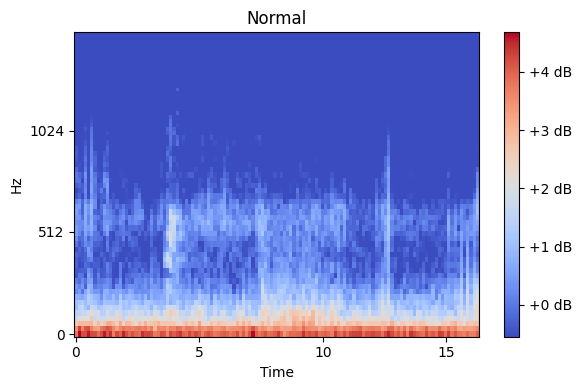

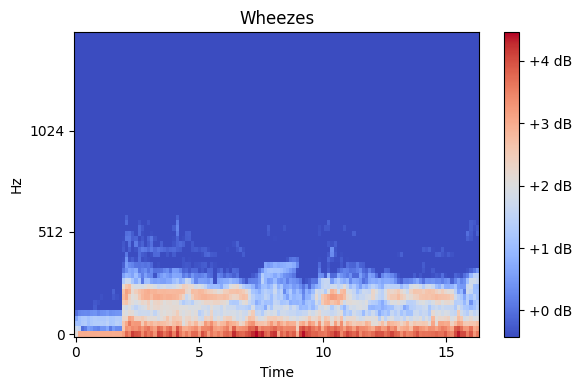

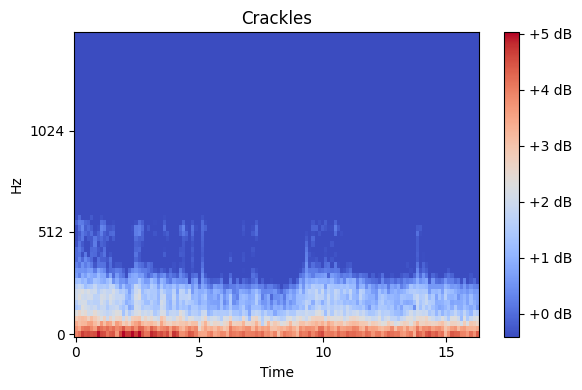

In [103]:
import matplotlib.pyplot as plt
import librosa.display

def plot_spectrogram(spec, title="Spectrogram"):
    plt.figure(figsize=(6, 4))
    librosa.display.specshow(spec, sr=4000, x_axis='time', y_axis='mel')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

classes_to_plot = ["Normal", "Wheezes", "Crackles"]

for cls in classes_to_plot:
    sample = df[df["sound_class"] == cls].iloc[0]

    file_path = AUDIO_DIR / sample["filename"]
    spec = extract_log_mel(str(file_path))
    spec = pad_or_truncate(spec)
    spec = (spec - spec.mean()) / (spec.std() + 1e-6)

    plot_spectrogram(spec, title=cls)

In [104]:
# Sound classification
sound_encoder = LabelEncoder()
df["sound_label"] = sound_encoder.fit_transform(df["sound_class"])

# Disease classification
disease_encoder = LabelEncoder()
df["disease_label"] = disease_encoder.fit_transform(df["diagnosis"])

In [105]:
class LungDataset(Dataset):
    def __init__(self, df, audio_dir, label_col):
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        file_path = self.audio_dir / row["filename"]

        spec = extract_log_mel(str(file_path))
        spec = pad_or_truncate(spec)
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        spec = torch.tensor(spec).unsqueeze(0).float()
        label = torch.tensor(row[self.label_col]).long()

        return spec, label

In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 16 * 32, 128)  # adjust based on input size
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
    
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### k-fold cross val

In [107]:
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupKFold
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

gkf = GroupKFold(n_splits=5)

fold_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df, groups=df["patient_id"])
):
    print(f"\nFold {fold}")

    train_df = df.iloc[train_idx]
    val_df   = df.iloc[val_idx]

    train_dataset = LungDataset(train_df, AUDIO_DIR, "sound_label")
    val_dataset   = LungDataset(val_df, AUDIO_DIR, "sound_label")

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=16)

    classes = np.arange(len(sound_encoder.classes_))

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_df["sound_label"]
    )

    weights = torch.tensor(weights, dtype=torch.float).to(device)

    model = SimpleCNN(num_classes=len(sound_encoder.classes_)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(50):
        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader):.3f}")

    # 🔹 Validation
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            outputs = model(X)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Fold {fold} F1: {f1:.3f}")

    fold_f1_scores.append(f1)

print("\nFinal Results:")
print("Mean F1:", np.mean(fold_f1_scores))
print("Std F1:", np.std(fold_f1_scores))


Fold 0
Epoch 0 | Loss: 1.192
Epoch 1 | Loss: 1.082
Epoch 2 | Loss: 0.968
Epoch 3 | Loss: 0.755
Epoch 4 | Loss: 0.546
Epoch 5 | Loss: 0.384
Epoch 6 | Loss: 0.294
Epoch 7 | Loss: 0.243
Epoch 8 | Loss: 0.185
Epoch 9 | Loss: 0.169
Epoch 10 | Loss: 0.114
Epoch 11 | Loss: 0.084
Epoch 12 | Loss: 0.070
Epoch 13 | Loss: 0.060
Epoch 14 | Loss: 0.054
Epoch 15 | Loss: 0.063
Epoch 16 | Loss: 0.048
Epoch 17 | Loss: 0.046
Epoch 18 | Loss: 0.048
Epoch 19 | Loss: 0.093
Epoch 20 | Loss: 0.128
Epoch 21 | Loss: 0.068
Epoch 22 | Loss: 0.043
Epoch 23 | Loss: 0.036
Epoch 24 | Loss: 0.060
Epoch 25 | Loss: 0.059
Epoch 26 | Loss: 0.041
Epoch 27 | Loss: 0.047
Epoch 28 | Loss: 0.032
Epoch 29 | Loss: 0.027
Epoch 30 | Loss: 0.027
Epoch 31 | Loss: 0.056
Epoch 32 | Loss: 0.050
Epoch 33 | Loss: 0.052
Epoch 34 | Loss: 0.038
Epoch 35 | Loss: 0.034
Epoch 36 | Loss: 0.026
Epoch 37 | Loss: 0.022
Epoch 38 | Loss: 0.024
Epoch 39 | Loss: 0.026
Epoch 40 | Loss: 0.049
Epoch 41 | Loss: 0.054
Epoch 42 | Loss: 0.029
Epoch 43 | Lo

### 80/20 single split

In [95]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1)

train_idx, test_idx = next(
    gss.split(df, groups=df["patient_id"])
)

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

train_dataset = LungDataset(train_df, AUDIO_DIR, "sound_label")
test_dataset  = LungDataset(test_df, AUDIO_DIR, "sound_label")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 261, Test samples: 66


In [96]:
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

classes = np.unique(train_df["sound_label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["sound_label"]
)

weights = torch.tensor(weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

model = SimpleCNN(num_classes=len(sound_encoder.classes_))
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} | Loss: {total_loss:.3f}")

Epoch 0 | Loss: 20.653
Epoch 1 | Loss: 18.230
Epoch 2 | Loss: 16.288
Epoch 3 | Loss: 12.366
Epoch 4 | Loss: 7.723
Epoch 5 | Loss: 4.574
Epoch 6 | Loss: 3.183
Epoch 7 | Loss: 2.109
Epoch 8 | Loss: 1.358
Epoch 9 | Loss: 0.916
Epoch 10 | Loss: 0.574
Epoch 11 | Loss: 0.396
Epoch 12 | Loss: 0.247
Epoch 13 | Loss: 0.248
Epoch 14 | Loss: 0.142
Epoch 15 | Loss: 0.159
Epoch 16 | Loss: 0.082
Epoch 17 | Loss: 0.064
Epoch 18 | Loss: 0.052
Epoch 19 | Loss: 0.043
Epoch 20 | Loss: 0.035
Epoch 21 | Loss: 0.031
Epoch 22 | Loss: 0.027
Epoch 23 | Loss: 0.025
Epoch 24 | Loss: 0.022
Epoch 25 | Loss: 0.020
Epoch 26 | Loss: 0.020
Epoch 27 | Loss: 0.017
Epoch 28 | Loss: 0.015
Epoch 29 | Loss: 0.013
Epoch 30 | Loss: 0.012
Epoch 31 | Loss: 0.012
Epoch 32 | Loss: 0.010
Epoch 33 | Loss: 0.010
Epoch 34 | Loss: 0.009
Epoch 35 | Loss: 0.009
Epoch 36 | Loss: 0.009
Epoch 37 | Loss: 0.007
Epoch 38 | Loss: 0.007
Epoch 39 | Loss: 0.007
Epoch 40 | Loss: 0.006
Epoch 41 | Loss: 0.006
Epoch 42 | Loss: 0.005
Epoch 43 | Loss: 

In [97]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)

        outputs = model(X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=sound_encoder.classes_))

              precision    recall  f1-score   support

    Crackles       0.38      0.33      0.35        18
      Normal       0.36      0.19      0.24        27
     Wheezes       0.25      0.43      0.32        21

    accuracy                           0.30        66
   macro avg       0.33      0.32      0.30        66
weighted avg       0.33      0.30      0.30        66



<Axes: >

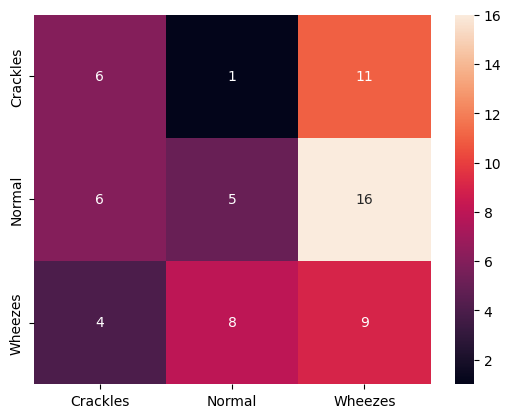

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=sound_encoder.classes_,
            yticklabels=sound_encoder.classes_)